In [1]:
import pandas as pd
import os
import numpy as np
import json
import collections

In [2]:
from typing import List, Optional
from Bio import Phylo

def add_feature(existing_features, new_feature):
    return existing_features + (new_feature,)
    
def tip_order_from_nexus_biopython(
    nexus_path: str,
    tree_label: Optional[str] = None
) -> List[str]:
    """
    Returns the left-to-right tip (sample) order from a NEXUS file using Biopython.
    If `tree_label` is given, picks that named tree; else the first tree in the file.
    """
    trees = list(Phylo.parse(nexus_path, "nexus"))
    if not trees:
        raise ValueError("No trees found in NEXUS file.")

    if tree_label is not None:
        matches = [t for t in trees if (t.name or "") == tree_label]
        if not matches:
            raise ValueError(f"Tree labeled '{tree_label}' not found.")
        tree = matches[0]
    else:
        tree = trees[0]

    tip_order = [clade.name for clade in tree.find_clades(order="preorder") if clade.is_terminal()]
    return tip_order

In [3]:
phylogeneticOrder=()
tips_bio = tip_order_from_nexus_biopython("/LeeLab/HPRC/chromosomeY/Information/phylogeny/142males_HGSVC_HPRC_CEPH_241125_150M-FOR_SHARING.nex")         # first tree

for sample in tips_bio:
    phylogeneticOrder = add_feature(phylogeneticOrder, sample)
   
print(phylogeneticOrder)
print(len(phylogeneticOrder))

haplogroups={}
phylDF = pd.read_csv("/LeeLab/HPRC/chromosomeY/HPRC_HGSVC3_sample_annotations_20March2025.txt",sep='\t')#
phylDF['GoodSampleNames']=[x.split("/")[1] if '/' in x else x for x in phylDF['sample']]
phylDF.set_index("GoodSampleNames", inplace=True)

for sample in phylogeneticOrder:
    if sample in phylDF.index:
        haplogroups[sample]=phylDF.at[sample,'haplogroup_ISOGG_v15.73']
    else:
        continue

haplogroups['NA12877']='R1b1a1b1a1a2e2'
haplogroups['NA12882']='R1b1a1b1a1a2e2'
haplogroups['NA12886']='R1b1a1b1a1a2e2'
haplogroups['200080']='R1b1a1b1a1a1c2b2b1a'
haplogroups['200084']='R1b1a1b1a1a1c2b2b1a'
haplogroups['200085']='R1b1a1b1a1a1c2b2b1a'

print(len(haplogroups))

('HG02984', 'HG01890', 'HG02647', 'HG02666', 'HG02668', 'HG03225', 'NA19043', 'NA19384', 'HG005', 'NA18952', 'NA18983', 'HG02572', 'HG03248', 'HG03098', 'HG03050', 'NA19239', 'HG01074', 'HG01109', 'HG01106', 'NA19331', 'HG01252', 'HG01457', 'HG03065', 'HG02717', 'HG03471', 'HG02011', 'HG03371', 'HG02486', 'HG02965', 'HG03139', 'NA19443', 'NA19317', 'NA19347', 'NA20346', 'HG02145', 'HG02258', 'HG02953', 'HG03130', 'HG03521', 'HG02554', 'NA18879', 'HG03209', 'NA18522', 'NA19700', 'HG02055', 'NA19705', 'NA18612', 'NA18620', 'HG04157', 'NA18989', 'NA18971', 'NA18974', 'HG02040', 'NA20870', 'HG03710', 'HG01099', 'HG03579', 'NA21093', 'HG04187', 'HG03009', 'HG03942', 'HG01167', 'HG00140', 'HG00321', 'NA20905', 'HG02492', 'HG02735', 'NA20805', 'NA20809', 'HG01255', 'HG01258', 'HG01433', 'HG003', 'HG002', 'HG03688', 'HG04199', 'HG01192', 'HG01530', 'HG03742', 'NA18608', 'NA18747', 'HG00280', 'HG00329', 'HG00290', 'HG00358', 'HG02015', 'HG02083', 'HG02514', 'HG02074', 'NA18534', 'HG02027', 'HG0

In [4]:
ampliconicDataframe=pd.read_csv('/LeeLab/HPRC/chromosomeY/Data/AmpliconicGenes/HGSVC3_HPRC_CEPH-AmpliconicGenes_combined_wLiftOff_plusManualAnnotation_nodbGaPSamples.09132025.csv')

In [5]:
ampliconicDataframe[(ampliconicDataframe['geneCompletenessInfo']=='Full_Exon_Copy') &(ampliconicDataframe['geneName']=='TSPY1') & (ampliconicDataframe['contig'].str.contains("_chrY"))]['AverageExonDivergence'].describe()

count    4685.000000
mean        0.242647
std         0.095277
min         0.033333
25%         0.183333
50%         0.216667
75%         0.266667
max         0.716667
Name: AverageExonDivergence, dtype: float64

In [6]:
seqClust = pd.read_csv("/LeeLab/HPRC/chromosomeY/Data/AmpliconicGenes/RBMY_Plus_Flanking/RBMY_Upstream_Motif_Groupings_wSeqeunceCluster.csv").set_index('Unnamed: 0')

In [31]:
with open('/LeeLab/HPRC/chromosomeY/Data/AmpliconicGenes/RBMY_Plus_Flanking/RBMY_Upstream_Motif_hits.json') as json_file:
    dataDict = json.load(json_file)

In [32]:
dataDict.keys()

dict_keys(['SeqPromoter:1', 'SeqPromoter:2', 'SeqPromoter:3', 'SeqPromoter:4', 'SeqPromoter:5', 'SeqPromoter:6', 'SeqPromoter:7', 'SeqPromoter:8', 'SeqPromoter:9', 'SeqPromoter:10', 'SeqPromoter:11', 'SeqPromoter:12', 'SeqPromoter:13', 'SeqPromoter:14', 'SeqPromoter:15', 'SeqPromoter:16', 'SeqPromoter:17', 'SeqPromoter:18'])

In [33]:
clusterNetworkDF=pd.read_csv("/LeeLab/HPRC/chromosomeY/Data/AmpliconicGenes/RBMY_Plus_Flanking/RBMY_Upstream_Motif_Groupings.csv")

In [37]:
clusterNetworkDF2=pd.read_csv("/LeeLab/HPRC/chromosomeY/Data/AmpliconicGenes/RBMY_Plus_Flanking/RBMY_Upstream_Motif_Groupings.csv").set_index("Unnamed: 0")

In [39]:
clusterNetworkDF2['SeqCluster']=[seqClust.at[x,'SequenceCluster'] for x in clusterNetworkDF2.index]

In [41]:
clusterNetworkDF2[clusterNetworkDF2['SeqCluster']=='SeqPromoter:7']

,cluster,color,SeqCluster
Unnamed: 0,,,
HG03248_chrY:23085719-23100162,0,#fa00dd,SeqPromoter:7
HG03248_chrY:23132794-23147237,0,#fa00dd,SeqPromoter:7
HG02572_chrY:22846752-22861197,0,#fa00dd,SeqPromoter:7
HG03098_chrY:22589338-22603779,0,#fa00dd,SeqPromoter:7
HG03050_chrY:22774456-22788901,0,#fa00dd,SeqPromoter:7


In [27]:
clusterNetworkDF['Gene']='RBMY'

In [28]:
clusterNetworkDF

,Unnamed: 0,cluster,color,Gene
0,NA18522_chrY:23204254-23218697,0,#33a02c,RBMY
1,NA18522_chrY:23227789-23242234,0,#fa00dd,RBMY
2,NA18522_chrY:23251326-23265772,0,#33a02c,RBMY
3,NA18522_chrY:23274864-23289310,0,#ff7f00,RBMY
4,NA18522_chrY:23580297-23594744,0,#fcba03,RBMY
...,...,...,...,...
1033,NA19705_chrY:23710179-23724625,0,#ff7f00,RBMY
1034,NA19705_chrY:24015599-24030048,0,#fcba03,RBMY
1035,NA19705_chrY:24039141-24053586,0,#e31a1c,RBMY
1036,NA19705_chrY:24304067-24318509,1,#1f78b4,RBMY


In [11]:
clusterNetworkDF.to_csv("/rbmy.csv")

In [17]:
len(dataDict['SeqPromoter:1']['plus'])

40

In [18]:
len(dataDict['SeqPromoter:4']['plus'])

33

In [21]:
newDFList=[]
for sublist in dataDict['SeqPromoter:1']['plus']:
    sublist.append('SeqPromoter:1')
    newDFList.append(sublist)

#for sublist in dataDict['SeqPromoter:1']['minus']:
#    sublist.append('SeqPromoter:1')
#    newDFList.append(sublist)

for sublist in dataDict['SeqPromoter:4']['plus']:
    sublist.append('SeqPromoter:4')
    newDFList.append(sublist)

#for sublist in dataDict['SeqPromoter:4']['minus']:
#    sublist.append('SeqPromoter:4')
#    newDFList.append(sublist) 

In [22]:
newDF = pd.DataFrame(data=newDFList)
newDF['NewStart']=[1000-x for x in newDF[0]]
newDF['NewEnd']=[1000-x for x in newDF[1]]
newDF.sort_values(by=['NewStart'], inplace=True)

cols = {0:"Start_raw", 1:"End_raw", 2:"Strand", 3:"TF", 4:"JasparID",
        5:"Unused1", 6:"Motif", 7:"MotifRC", 8:"SeqCol1", 9:"SeqCol2", 10:"SeqCol3",'NewStart':'NewStart','NewEnd':'NewEnd'}
newDF = newDF.rename(columns=cols)

In [23]:
newDF

,Start_raw,End_raw,Strand,TF,JasparID,Unused1,Motif,MotifRC,SeqCol1,NewStart,NewEnd
42,915,923,+,ZNF770,MA2099.1,None,CGGCCTCA,CGGCCTCA,SeqPromoter:4,85,77
4,915,923,+,ZNF770,MA2099.1,None,CGGCCTCA,CGGCCTCA,SeqPromoter:1,85,77
45,857,862,+,Ahr::Arnt,MA0006.2,None,GCGTG,GCGTG,SeqPromoter:4,143,138
7,857,862,+,Ahr::Arnt,MA0006.2,None,GCGTG,GCGTG,SeqPromoter:1,143,138
8,846,851,+,ARNT::HIF1A,MA0259.2,None,ACGTG,ACGTG,SeqPromoter:1,154,149
...,...,...,...,...,...,...,...,...,...,...,...
19,74,82,+,KLF4,MA0039.5,None,CCCCACCC,CCCCACCC,SeqPromoter:1,926,918
64,67,73,+,SP5,MA1965.2,None,CCTCCC,CCTCCC,SeqPromoter:4,933,927
31,67,73,+,SP5,MA1965.2,None,CCTCCC,CCTCCC,SeqPromoter:1,933,927
14,30,36,+,HIC2,MA0738.2,None,GTGCCC,RTGCCC,SeqPromoter:1,970,964


In [24]:
group1=newDF[newDF['SeqCol1']=='SeqPromoter:1'].copy()
group2=newDF[newDF['SeqCol1']=='SeqPromoter:4'].copy()

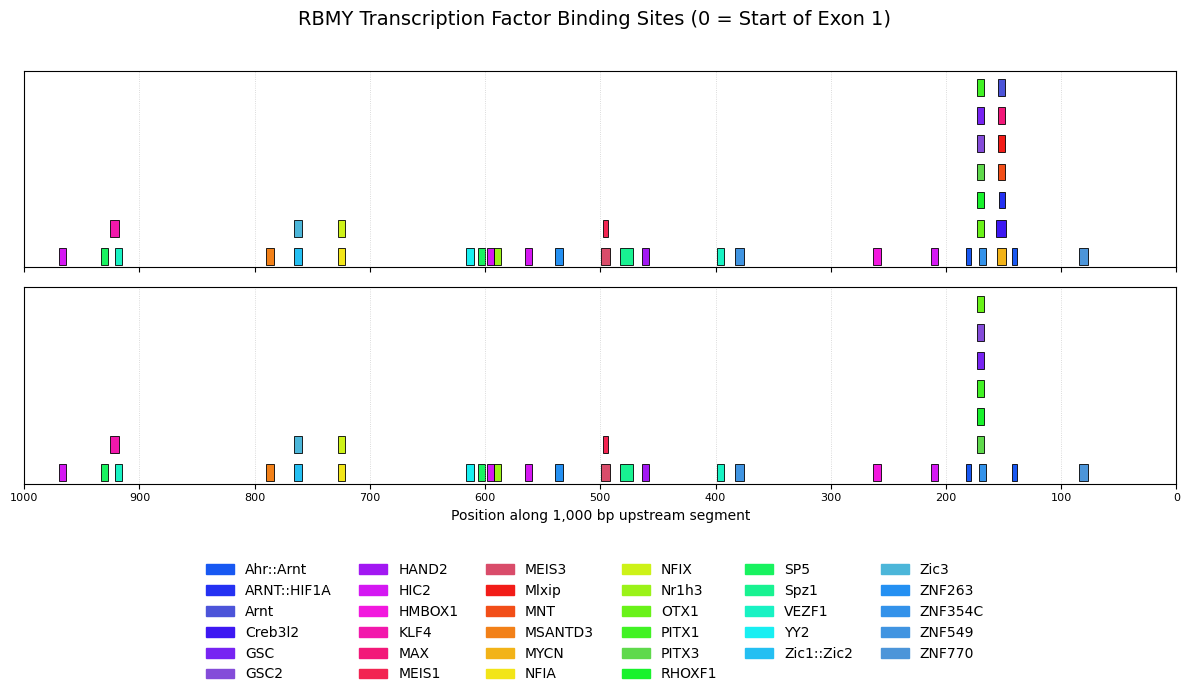

In [25]:
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.patches import Rectangle
import numpy as np
import re, colorsys
from collections import defaultdict

dfs = [group1, group2]

all_tfs_series = pd.concat([df["TF"].astype(str).dropna() for df in dfs])
all_tfs_unique = sorted(all_tfs_series.unique().tolist())

def tf_stem(name: str, maxlen: int = 4) -> str:
    m = re.match(r"[A-Za-z]+", name)  
    if not m:
        return name.upper()
    return m.group(0).upper()[:maxlen]

stem_to_tfs = defaultdict(list)
for tf in all_tfs_unique:
    stem_to_tfs[tf_stem(tf)].append(tf)

for stem in stem_to_tfs:
    stem_to_tfs[stem] = sorted(stem_to_tfs[stem])

stems = sorted(stem_to_tfs.keys())
n_stems = max(1, len(stems))

phi = (1 + 5 ** 0.5) / 2
base_hues = [(i / n_stems + 1 / phi) % 1.0 for i in range(n_stems)]
stem_to_hue = {stem: base_hues[i] for i, stem in enumerate(stems)}

def nth_shade(h, k, K):
    if K == 1:
        s, v = 0.90, 0.95
    else:
        s = 0.85 - 0.20 * (k / max(1, K - 1))   
        v = 0.95 - 0.10 * (k / max(1, K - 1))   
    r, g, b = colorsys.hsv_to_rgb(h, s, v)
    return (r, g, b)

color_map = {}
legend_items = [] 
for stem in stems:
    h = stem_to_hue[stem]
    tf_list = stem_to_tfs[stem]
    for k, tf in enumerate(tf_list):
        col = nth_shade(h, k, len(tf_list))
        color_map[tf] = col
        legend_items.append((tf, col))


def prepare_intervals(df):
    df = df[["TF", "Strand", "NewStart", "NewEnd"]].copy()
    df["start"] = df[["NewStart", "NewEnd"]].min(axis=1).clip(0, 1000)
    df["end"]   = df[["NewStart", "NewEnd"]].max(axis=1).clip(0, 1000)
    df = df[df["end"] > df["start"]].reset_index(drop=True)

    intervals = df.sort_values(["start", "end"]).reset_index(drop=True)
    lanes_end, lane_idx = [], []
    for _, row in intervals.iterrows():
        for ln, last_end in enumerate(lanes_end):
            if row["start"] >= last_end:
                lanes_end[ln] = row["end"]; lane_idx.append(ln); break
        else:
            lanes_end.append(row["end"]); lane_idx.append(len(lanes_end)-1)
    intervals["lane"] = lane_idx
    return intervals, len(lanes_end)

prepared = [prepare_intervals(d) for d in dfs]
interval_lists = [p[0] for p in prepared]
lane_counts    = [p[1] for p in prepared]
max_lanes = max(lane_counts) if lane_counts else 1


fig_w = 12
fig_h_per = 3
lane_height = 0.8
y_pad = 0.1

fig, axes = plt.subplots(
    nrows=len(dfs), ncols=1, figsize=(fig_w, fig_h_per * len(dfs)),
    sharex=True, sharey=False, constrained_layout=False
)
if len(dfs) == 1:
    axes = [axes]

for ax, intervals, n_lanes in zip(axes, interval_lists, lane_counts):
    for _, r in intervals.iterrows():
        y = r["lane"] 
        x0, x1 = r["start"], r["end"]
        width = x1 - x0
        col = color_map.get(r["TF"], (0.5, 0.5, 0.5))

        ax.add_patch(Rectangle((x0, y + y_pad),
                               width, lane_height - 2*y_pad,
                               facecolor=col, edgecolor="black", linewidth=0.6))

    ax.set_xlim(0, 1000)
    ax.set_ylim(0, max_lanes)
    ax.set_yticks([])
    ax.invert_xaxis()
    ax.grid(axis="x", linestyle=":", linewidth=0.6, alpha=0.6)

axes[-1].set_xlabel("Position along 1,000 bp upstream segment")
ticks = np.arange(0, 1001, 100)
axes[-1].set_xticks(ticks)
axes[-1].tick_params(axis='x', labelsize=8)

fig.suptitle("RBMY Transcription Factor Binding Sites (0 = Start of Exon 1)", fontsize=14, y=0.96)
plt.tight_layout(rect=[0, 0.08, 1, 0.94])  # leave space at bottom for legend

handles = [Rectangle((0, 0), 1, 1, color=col) for (tf, col) in legend_items]
labels  = [tf for (tf, col) in legend_items]
fig.legend(handles, labels, loc='lower center',
           ncol=min(6, len(labels)), frameon=False, bbox_to_anchor=(0.5, -0.18))

#plt.savefig("/LeeLab/HPRC/chromosomeY/Figures/RBMY/RBMY_Submission/RBMY_tf_binding_sites_family_colors.pdf", bbox_inches="tight", dpi=300)
#plt.savefig("/LeeLab/HPRC/chromosomeY/Figures/RBMY/RBMY_Submission/RBMY_tf_binding_sites_family_colors.jpg", bbox_inches="tight", dpi=300)
plt.show()


In [27]:
set(group1['TF'])-set(group2['TF'])

{'ARNT::HIF1A', 'Arnt', 'Creb3l2', 'MAX', 'MNT', 'MYCN', 'Mlxip'}